In [1]:
# Importing relevant python packages
import numpy as np 
import matplotlib.pyplot as plt 

# Creating a potential function 
def potential(x):   
    
    """
    Calculating the potential energy matrix for a quantum harmonic oscillator using a discrete approximation of position

    Parameters:
    -----------
    - x: 1D numpy array representing the positions

    Returns:
    --------
    - v: N by N numpy arrray, the potential energy matrix
    """
    
    # A local variable equal to the number of values in the position array 
    N = len(x) 
    
    # Creating an N by N array for the values of potential
    v = np.zeros((N,N)) 
    
    for i in range(N):
        
        # Adding each value of potential in the diagonal of array 
        v[i,i] = x[i]**2 
        
    return v

# NOTE - I have outputted an N by N array as the size of arrays will help in the hamiltonian function

Text(0.5, 0, 'Position (a)')

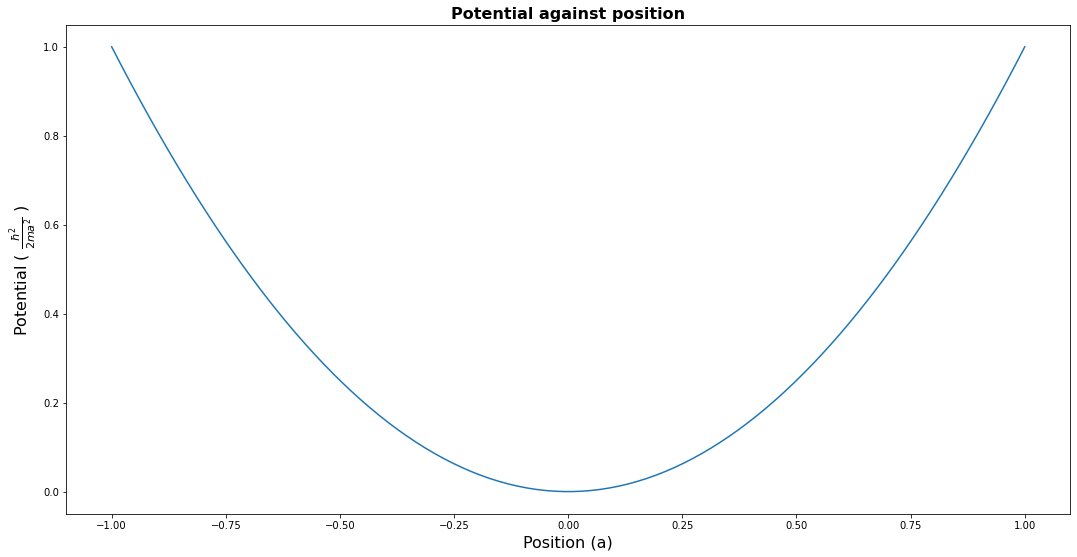

In [2]:
# Creating an array for x values with equal spacing to test the potential function
x_test = np.linspace(1,-1,100) 

# Taking the diagonal of the N by N matrix
potential_diag = np.diag(potential(x_test)) 

# Creating a plot for potential against time 
plt.figure(figsize = (18,9)) # Adjusting the plot size so the plot is easier to observe
plt.plot(x_test, potential_diag) 
plt.title('Potential against position', fontweight = 'bold', fontsize = 16) # Changing font size/boldness to make easier to read 
plt.ylabel('Potential ( $\\frac{\\hbar^2}{2ma^2}$ )', fontsize = 16)
plt.xlabel('Position (a)', fontsize = 16)

In [3]:
# Defining the function for the hamiltonian matrix
def hamiltonian(x, v): 
    
    """
    Calculating the hamiltonian matrix for the quantum harmonic oscillator using discrete approximations to find kinetic energy 

    Parameters:
    -----------
    - x: 1D numpy array representing the positions
    - v: N by N numpy array, a potential matrix 

    Returns:
    --------
    - H: N by N numpy array, the hamiltonian matrix
    """
    # A local variable, N, equal to the number of values in the position array 
    N = len(x)
    
    # A hamiltonian array of dimension N by N. The array is full of zeroes
    H = np.zeros((N,N)) 
    
    # Defining delta x. This is the smallest difference between two adjacent position values
    dx = x[1] - x[0]
    
    
    # Constructing the kinetic energy matrix 
    D = np.diag(2 / dx**2 * np.ones(len(x))) - np.diag(1 / dx**2 * np.ones(len(x) - 1), k=1) - np.diag(1 / dx**2 * np.ones(len(x) - 1), k=-1)

    # Constructing the Hamiltonian matrix H by adding D and v, the potential
    H = D + v
    
    
    return H

# NOTE - The use of potential being a N by N array initially allows for addition straight away with the kinetic energy matrix

In [4]:
# Define discrete position points and potential values
x_test2 = np.linspace(-1, 1, 6)  # Creating a position array.

# Calling up the potential function 
potential_values = potential(x_test2)

# Call the function to get the Hamiltonian matrix
H_matrix = hamiltonian(x_test2, potential_values)

# Outputting the hamiltonian matrix to check if it is correct
print(H_matrix)

[[13.5  -6.25  0.    0.    0.    0.  ]
 [-6.25 12.86 -6.25  0.    0.    0.  ]
 [ 0.   -6.25 12.54 -6.25  0.    0.  ]
 [ 0.    0.   -6.25 12.54 -6.25  0.  ]
 [ 0.    0.    0.   -6.25 12.86 -6.25]
 [ 0.    0.    0.    0.   -6.25 13.5 ]]


+-------------------+---------------------+---------------------+------------------------------------------+
| Eigenvalue Number | Computed Eigenvalue | Expected Eigenvalue | Difference Between Expected and Computed |
+-------------------+---------------------+---------------------+------------------------------------------+
|        1.0        | 0.9999909818962551  |         1.0         |           9.01810374487333e-06           |
|        2.0        | 2.9999549091338835  |         3.0         |          4.509086611648172e-05           |
|        3.0        | 4.9998827628112315  |         5.0         |          0.0001172371887685486           |
|        4.0        | 6.9997745420637365  |         7.0         |          0.00022545793626349564          |
|        5.0        |  8.99963024778386   |         9.0         |          0.0003697522161392186           |
|        6.0        | 10.999449900542183  |        11.0         |          0.0005500994578166996           |
|        7.0       

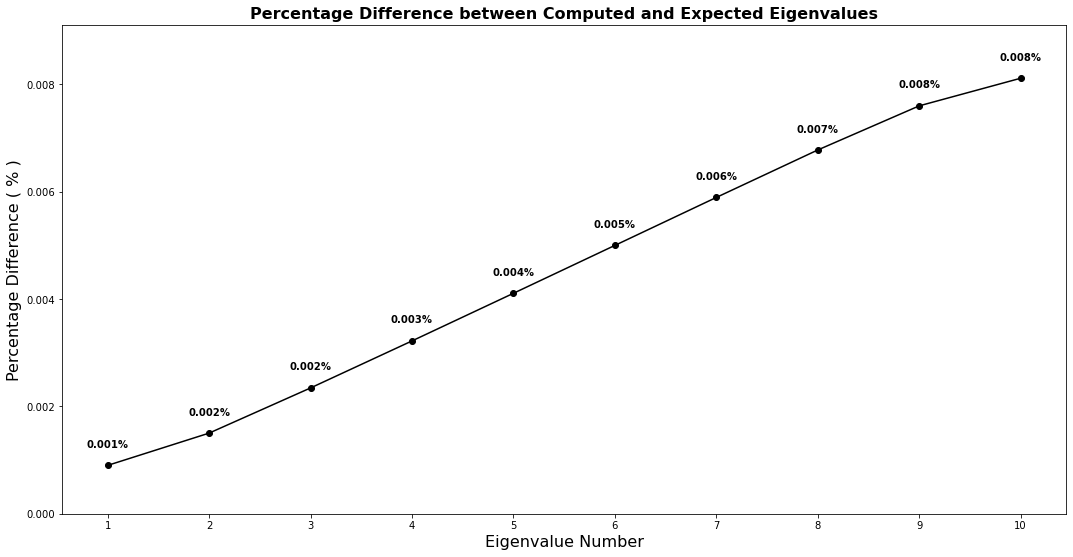

In [5]:
from scipy.linalg import eigh   # Importing eigh from SciPy to take eigenvectors and eigenvalues for the hamiltonian 
import pandas as pd # Importing pandas to create tables
from tabulate import tabulate # Importing tabulate to create tables

# Defining a larger set of x points for better accuracy
x_points = np.linspace(-6, 6, 1000)

# Using the potential function using x values with a greater amount of points for accuracy 
potential_values_large = potential(x_points)

# Calling the hamiltonian function taking arguments, the new array of x points and new potential values. Then defining it as the Hamiltonian matrix
H_matrix = hamiltonian(x_points, potential_values_large)

# Finding the eigenvalues and eigenvectors
eigenvalues, eigenvectors = eigh(H_matrix)

# Sorting eigenvalues and eigenvectors to make sure they are in the correct order
sort = np.argsort(eigenvalues)
eigenvalues = eigenvalues[sort]
eigenvectors = eigenvectors[:, sort]

# Generating expected eigenvalues
expected_eigenvalues = (2 * np.arange(10) + 1).astype(int)

# Creating a list of lists to then put into a dataframe to create a table
data = {
    'Eigenvalue Number': np.arange(1, 11), # Adding eigenvalue numbers
    'Computed Eigenvalue': np.abs(eigenvalues[:10]), # Adding first 10 eigenvalues to table 
    'Expected Eigenvalue': expected_eigenvalues, # Adding expected eigenvalues to table 
    'Difference Between Expected and Computed': np.abs(eigenvalues[:10] - expected_eigenvalues[:10])
}

# Creating a dataframe using the list of lists
dframe = pd.DataFrame(data)

# Creating a table using the DataFrame. The formatting of the table is shown below. 
table = tabulate(dframe, headers = 'keys', tablefmt='pretty', showindex=False)

# Printing the table 
print(table)

# Creating percentage difference values for each eigenvalue 
percentage_difference = 100 * np.abs((eigenvalues[:10] - expected_eigenvalues[:10]) / expected_eigenvalues[:10])

# Making a figure size that is large enough to present data 
plt.figure(figsize=(18,9))

# Creating a plot of percentage difference against eigenvalue 
plt.plot(np.arange(1, 11), percentage_difference, marker = '.', alpha = 1, markersize = 12, c = 'black')
plt.title('Percentage Difference between Computed and Expected Eigenvalues', fontweight = 'bold', fontsize = 16)
plt.xlabel('Eigenvalue Number', fontsize = 16)
plt.ylabel('Percentage Difference ( % )', fontsize = 16)

# Increasing the y-value limit to allow the percentage difference to show for the largest value
plt.ylim(0, np.max(percentage_difference) + 0.001)

# To make sure every eigenvalue is expressed on the x-axis and nothing is left out. 
plt.xticks(np.arange(1, 11, 1))

# Annotating each point on the plot with its y-value
for x, y in zip(np.arange(1, 11), percentage_difference):
    plt.text(x, y + 0.0003, f'{y:.3f}%', fontsize=10, fontweight='bold', color='black', ha='center', va='bottom')

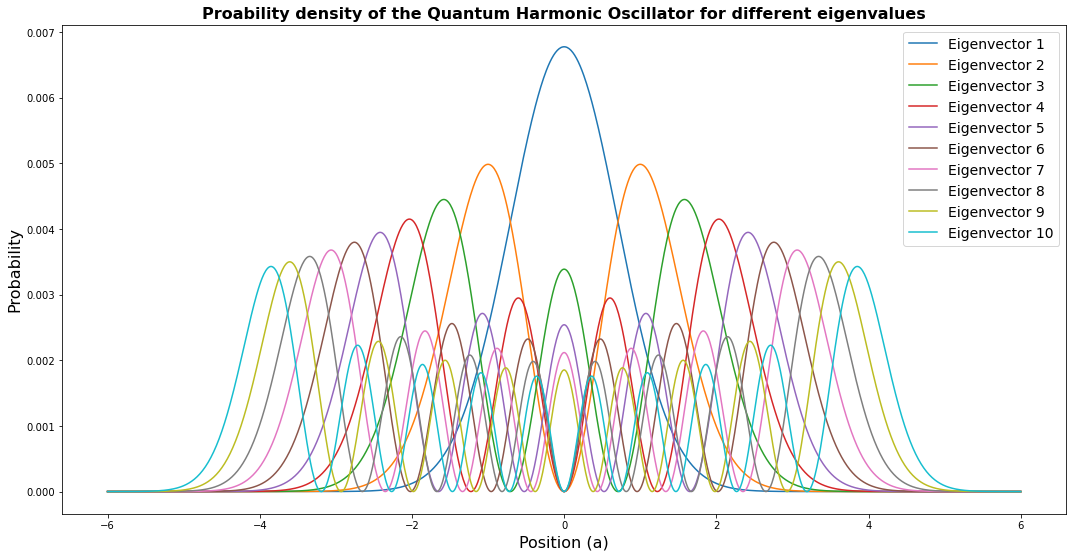

In [6]:
# Creating a figure that is a reasonable size 
plt.figure(figsize=(18, 9))

for i in range(10):  
    
    # Plot first 10 eigenvectors
    plt.plot(x_points, np.square(eigenvectors[:, i]), label=f'Eigenvector {i + 1}')

# Creating a plot to find the probability density of wavefunction using different eigenvalues 
plt.title('Proability density of the Quantum Harmonic Oscillator for different eigenvalues', fontsize = 16, fontweight = 'bold')
plt.xlabel('Position (a)', fontsize = 16)
plt.ylabel('Probability', fontsize = 16)
plt.legend(fontsize = 14)
plt.show()

In [7]:
# Creating a function for potential for the hydrogen atom
def potential_hydrogen(r, l):
    
    """
    Calculate the potential energy matrix for the hydrogen atom using discrete approximations for radial distances

    Parameters:
    -----------
    - r: 1D numpy array representing the radius 
    - l: Integer representing the angular momentum 

    Returns:
    --------
    - v: N by N numpy array, the potential energy matrix
    """
    
    # Length of radius array
    N = len(r) 
    
    # Creating an array of size N by N for the values of potential. It is not an 1D array form, so it is easier to use in the hamiltonian function. 
    v = np.zeros((N,N)) 
    
    # Creating a for loop to add values to potential based on radius and angular momentum 
    for i in range(N):
        v[i,i] = (-2 / r[i] ) + (l * (l + 1) / (r[i] ** 2))  
    
    return v

+-------------------+-----------------------+-----------------------+------------------------------------------+
| Eigenvalue Number |  Computed Eigenvalue  |  Expected Eigenvalue  | Difference Between Expected and Computed |
+-------------------+-----------------------+-----------------------+------------------------------------------+
|        1.0        |  -0.9901758788708719  |         -1.0          |           0.009824121129128116           |
|        2.0        |  -0.2493768661417448  |         -0.25         |          0.0006231338582551871           |
|        3.0        |  -0.1109876817208255  |  -0.1111111111111111  |          0.00012342939028560374          |
|        4.0        | -0.06246090820495305  |        -0.0625        |          3.909179504694993e-05           |
|        5.0        | -0.03998398079040691  |         -0.04         |          1.6019209593091943e-05          |
|        6.0        | -0.02777005057401559  | -0.027777777777777776 |          7.727203762186718

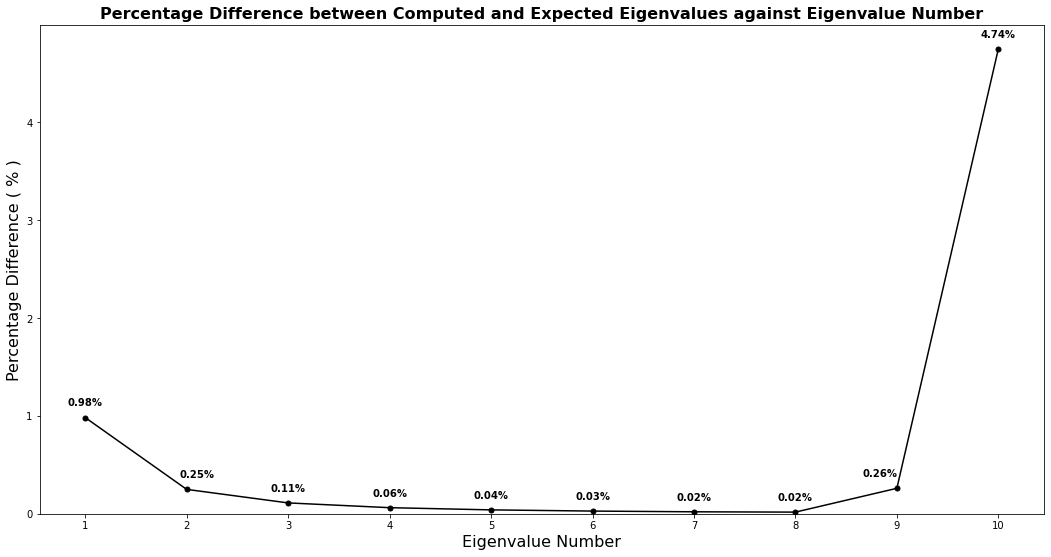

In [8]:
# Defining discrete radial distances
r_points = np.linspace(0, 200, 1000)

# Setting the angular momentum quantum number
l = 0  

# Calling up the potential for the hydrogen atom function. Taking in all radial distances except the first one which is 0. This is to avoid a diving by 0 error and is dealt with accordingly throughout the code to make sure everything else doesnt use the first value of distance.
potential_values_hydrogen = (potential_hydrogen(r_points[1:], l))

# Defining a new variable which is the output of the hamiltonian function. The inputs are the potential defined above and radial distances which again ignores the first value. The reason explained above.
H_matrix = hamiltonian(r_points[1:], potential_values_hydrogen)

# Finding eigenvalues and eigenvectors
eigenval, eigenvec = eigh(H_matrix)

# Sorting eigenvalues and eigenvectors to make sure they are in correct order
sort2 = np.argsort(eigenval)
eigenvalues_hydrogen = eigenval[sort2]
eigenvectors_hydrogen = eigenvec[:, sort2]

# Generating the expected eigenvalues
# NOTE - Due to the units of energy changing the expected eigenvalues will be not be equal to -13.6/n^2. Instead it will be equal to -1/n^2
expected_eigenvalues_h = - 1 / (np.square(np.arange(10)+1))


# Generating a list of lists to then create a dataframe and then create a table 
data2 = {
    'Eigenvalue Number': np.arange(1, 11),
    'Computed Eigenvalue': -1*np.abs(eigenvalues_hydrogen[:10]), # Needed to take np.abs of value due to the data type it is orginially in and it looks better in the table.
    'Expected Eigenvalue': expected_eigenvalues_h,
    'Difference Between Expected and Computed': np.abs(eigenvalues_hydrogen[:10] - expected_eigenvalues_h[:10])
}

# Creating a dataframe
dframe2 = pd.DataFrame(data2)

# Creating a table and the formatting is shown below 
table2 = tabulate(dframe2, headers= 'keys', tablefmt='pretty', showindex=False)
print(table2)

# Defining the percentage difference for each eigenvalue
percentage_difference = 100 * np.abs((eigenvalues_hydrogen[:10] - expected_eigenvalues_h[:10]) / expected_eigenvalues_h[:10])

# Creating a figure of large size 
plt.figure(figsize=(18,9))

# Making a plot for percentage difference against eigenvalues 
plt.plot(np.arange(1, 11), percentage_difference, marker = '.', alpha = 1, markersize = 10, c = 'black')
plt.title('Percentage Difference between Computed and Expected Eigenvalues against Eigenvalue Number', fontweight = 'bold', fontsize = 16)
plt.xlabel('Eigenvalue Number', fontsize = 16)
plt.ylabel('Percentage Difference ( % )', fontsize = 16)
plt.ylim(0, np.max(percentage_difference) + 0.25)  # Increasing the maximum value shown on the y-axis to allow the y-value to be displayed on each point

# To make sure every eigenvalue is expressed on the x-axis and nothing is left out. 
plt.xticks(np.arange(1, 11, 1))

# Annotating each bar with its y-value
for x, y in zip(np.arange(1, 11), percentage_difference):
    # Adjusting eigenvalues 2 and 9 to make sure the y-value above the point doesnt cross with the line 
    if x == 9 :
        plt.text(x - 0.17, y + 0.1, f'{y:.2f}%', fontsize=10, fontweight='bold', color='black', ha='center', va='bottom')
    elif x == 2:
        plt.text(x + 0.1, y + 0.1, f'{y:.2f}%', fontsize=10, fontweight='bold', color='black', ha='center', va='bottom')
    else:
        plt.text(x, y + 0.1, f'{y:.2f}%', fontsize=10, fontweight='bold', color='black', ha='center', va='bottom')


plt.show()


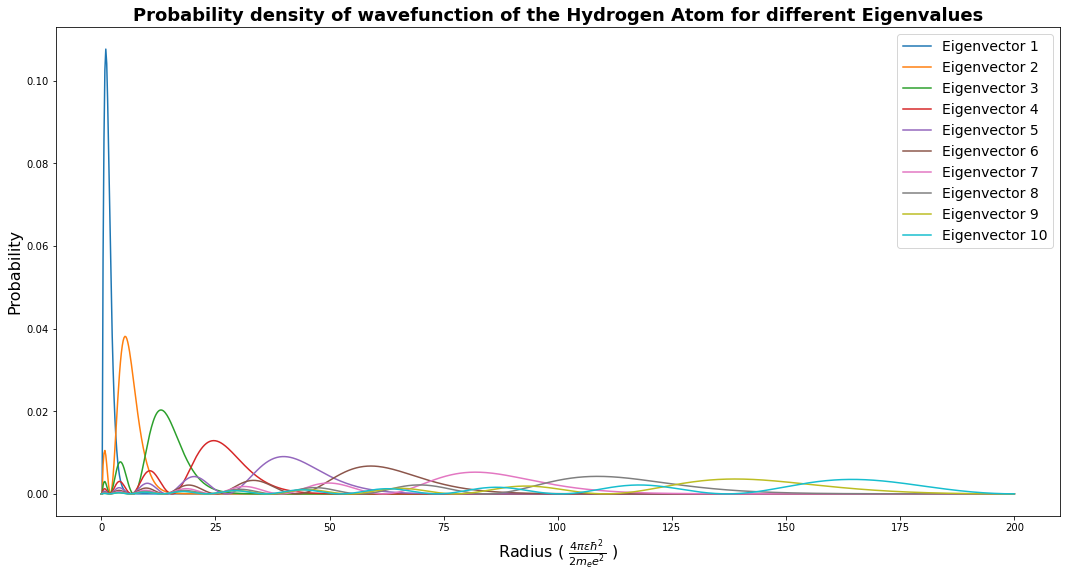

In [9]:
# Creating a figure with larger dimensions
plt.figure(figsize=(18, 9))

# Creating a for loop to plot the probability density 
for i in range(10): 
    
    # This is used to to re add the inital point of 0 radial distance back into the plot to complete it for each eigenvector
    p_density = np.concatenate(([0,0], eigenvectors_hydrogen[1:, i]*eigenvectors_hydrogen[1:, i]))
    
    # Creating a plot of probability denisty against radial distance for the wavefunction each eigenvector
    plt.plot(r_points, p_density , label=f'Eigenvector {i + 1}')
    
# Adding title, axis labels and a legend to the plot 
plt.title('Probability density of wavefunction of the Hydrogen Atom for different Eigenvalues', fontweight = 'bold', fontsize = 18)
plt.xlabel('Radius ( $\\frac{4\pi\\varepsilon\\hbar^2}{2m_e e^2}$ )', fontsize=16)
plt.ylabel('Probability', fontsize = 16)
plt.legend(fontsize = 14)
plt.show()


The code provided solutions to the quantum harmonic oscillator and hydrogen atom. Functions for both the hamiltonian matrix and potential matrix were created to find solutions for the wavefunctions for both the quantum harmonic oscillator and hydrogen atom. The potential matrix used a discrete approximation for position and the hamiltonian used discrete approximation of the 2nd derivative of the wavefunction with respect to position to find kinetic energy. Both the eigenvalues and the eigenvectors were found for the hamiltonian matrix, which corresponded to the energies and the wavefunctions respectively. The eigenvalues were presented in a table and the eigenvectors were plotted as probability densities. The probability densities were found by multiplying a specific eigenvector by itself. 

The solutions to both the quantum harmonic oscillator and the hydrogen atom used, eigh, from the SciPy library. This extracted eigenvalues and eigenvectors from a specific hamiltonian. This was specifically used as it is an easy and efficient way to extract eigenvalues and eigenvectors. Eigh was used as it only works on a symmetric hermitian matrix and a hamiltonian operator will always be hermitian. This will make the runtime quicker as it uses the advantage of symmetry to exploit structure and perform operations more efficiently. NumPy was imported and used all throughout the code to create arrays of different sizes, manipulate and operate on variables and numbers. Furthermore, Matplotlib was imported and used throughout the code to present data and error analysis graphically. In addition, pandas and tabulate were imported to present results and error analysis in a structured table. 
	
The main results showed the method used to find solutions for the quantum harmonic oscillator was far more accurate than the hydrogen atom. The percentage difference graphs show the quantum harmonic oscillator gave an error of 10 times greater accuracy. The number of values in each array for position and radial distance was both 1000 and was the same to make the comparison fair. The general trend for accuracies for the quantum harmonic oscillator showed that with the increasing eigenvalue number the percentage error increased. However, for the hydrogen atom the percentage error stayed around constant in value except for the first two and last two eigenvalues. The accuracy of the method is linked to the number of points used for position and radius, however when increasing to more than 1000 the run time of the program gets increasingly long and inefficient for a small increase in accuracy. In addition, the probability density graphs gave accurate curves, very alike to the actual curves. 

For every test that was done, small arrays were used to check the dimensions of arrays being outputted and the general shape of plots were all correct.

To conclude for both the hydrogen atom and the quantum harmonic oscillator, the code produces great accurate results.

